In [1]:
import cv2
import matplotlib.pyplot as plt

from inference_sdk import InferenceHTTPClient
import numpy as np

import chess
import chess.svg
import requests

from IPython.display import clear_output

In [2]:
def read_api_key(filepath=".secrets"):
    with open(filepath, "r") as file:
        return file.read().strip()

API_KEY = read_api_key()

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)


In [ ]:
WIDTH = 1280
HEIGHT = 960
boardCorners = []

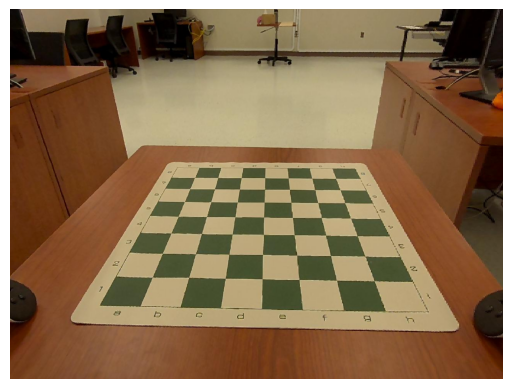

In [4]:
image = cv2.imread("received_images/test1.jpg")

imageShow = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(imageShow)
plt.axis("off")
plt.show()

In [ ]:
def extractBoardCorners(points, pattern_size):
    points = points.reshape(-1, 2)

    bottom_left = [int(points[0][0]),  int(points[0][1])]
    top_left = [int(points[pattern_size[0] - 1][0]),
                   int(points[pattern_size[0] - 1][1])]
    bottom_right = [int(points[-pattern_size[0]][0]),
                 int(points[-pattern_size[0]][1])]
    top_right = [int(points[-1][0]),  int(points[-1][1])]

    bottomCellSide = (bottom_right[0] - bottom_left[0]) // 6
    bottom_right[0] += int(bottomCellSide * 1.3)
    bottom_right[1] += int(bottomCellSide * 0.85)
    bottom_left[0] -= int(bottomCellSide * 1.3)
    bottom_left[1] += int(bottomCellSide * 0.85)

    topCellSide = (top_right[0] - top_left[0]) // 6
    top_right[0] += int(topCellSide * 0.95)
    top_right[1] -= int(topCellSide * 0.55)
    top_left[0] -= int(topCellSide * 0.95)
    top_left[1] -= int(topCellSide * 0.55)

    return [tuple(top_left), tuple(top_right), tuple(bottom_left), tuple(bottom_right)]

def getBoardCorners(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    pattern_size = (7, 7)

    res, corners = cv2.findChessboardCorners(gray, pattern_size, None)

    if res:
        return extractBoardCorners(corners, pattern_size)
    else:
        print("Chessboard corners not found.")
        return None
    


[(423, 404), (903, 407), (247, 775), (1068, 785)]
